In [ ]:
# !pip list

In [ ]:
import os

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
import PIL.Image, PIL.ImageOps
import PIL.ImageDraw
import PIL.ImageFont

In [ ]:
in_width = 75
in_height = 75
use_normalised_candidates = True

In [ ]:
def draw_single_bounding_box_on_image(image,ymin,xmin,ymax,xmax,color='red',thickness=1,display_str=''):
  draw = PIL.ImageDraw.Draw(image)
  im_width,im_height = image.size
  if use_normalised_candidates:
    (left,right,top,bottom) = (xmin*im_width,xmax*im_width,ymin*im_height,ymax*im_height)
  else:
    (left,right,top,bottom) = (xmin,xmax,ymin,ymax)

  draw.line([(left,top),(left,bottom),(right,bottom),(right,top),(left,top)],width=thickness,fill=color)

  if display_str:
      text_bottom = bottom + 5
      text_left = left
      try:
        font = PIL.ImageFont.truetype("arial.ttf", 15)
      except IOError:
        font = PIL.ImageFont.load_default()
      draw.text((text_left, text_bottom), display_str, fill=color, font=font)

In [ ]:
def draw_bounding_boxes_on_image(image,boxes,color=None,thickness = 1,display_str_list=()):
  boxes_shape = boxes.shape
  if not boxes_shape:
    return

  if len(boxes_shape) != 2 or boxes_shape[1]!=4:
    raise ValueError('Input must be of size [N,4]')

  colors = [color] * boxes_shape[0] if not isinstance(color, list) else color
  display_strings = [''] * boxes_shape[0] if not display_str_list else display_str_list

  if len(colors) != boxes_shape[0]:
      raise ValueError('Number of colors must match number of boxes.')
  if len(display_strings) != boxes_shape[0]:
       if len(display_str_list) < boxes_shape[0]:
           display_strings = list(display_str_list) + [''] * (boxes_shape[0] - len(display_str_list))
       else:
           raise ValueError('Number of display strings must match number of boxes.')


  for i in range(boxes_shape[0]):
      ymin, xmin, ymax, xmax = boxes[i]
      draw_single_bounding_box_on_image(image, ymin, xmin, ymax, xmax,
                                         color=colors[i], thickness=thickness,
                                         display_str=display_strings[i])

In [ ]:
def draw_bounding_boxes_on_image_array(image,boxes,color=None,thickness = 1,display_str_list=()):
    image_pil = PIL.Image.fromarray(image).convert('RGB')
    draw_bounding_boxes_on_image(image_pil,boxes,color=color,thickness=thickness,display_str_list=display_str_list)
    return np.array(image_pil)

In [ ]:
def dataset_to_numpy_util(training_dataset,validation_dataset,N):
  batch_train_ds = training_dataset.unbatch().batch(N)

  if tf.executing_eagerly():

    for validation_digits ,(validation_labels,validation_bboxes) in validation_dataset:
      validation_digits = validation_digits.numpy()
      validation_labels = validation_labels.numpy()
      validation_bboxes = validation_bboxes.numpy()
      break

    for training_digits, (training_labels,training_bboxes) in batch_train_ds:
      training_digits = training_digits.numpy()
      training_labels = training_labels.numpy()
      training_bboxes = training_bboxes.numpy()
      break

  validation_labels = np.argmax(validation_labels,axis=1)
  training_labels = np.argmax(training_labels,axis=1)

  return (training_digits,training_labels,training_bboxes,
          validation_digits,validation_labels,validation_bboxes)

matplotlib_fonts_dir = os.path.join(os.path.dirname(plt.__file__),'mpl-data/fonts/ttf')

In [ ]:
def create_digits_from_local_fonts(n):
  font_labels=[]

  img=PIL.Image.new('RGB',(25*n,25),color=(0,0,0))
  font1 = PIL.ImageFont.truetype(os.path.join(matplotlib_fonts_dir,'DejaVuSans.ttf'),size=25)
  font2 = PIL.ImageFont.truetype(os.path.join(matplotlib_fonts_dir,'STIXGeneral.ttf'),size=25)
  d = PIL.ImageDraw.Draw(img)

  for i in range (n):
    font_labels.append(i%10)
    d.text((7+i*25,0 if i<10 else -4),str(i%10),fill=(255,255,255),font=font1 if i<10 else font2)
  digits_list = []
  for i in range(n):
      pass
  return None, None

In [ ]:
def display_digits_with_boxes(digit,predictions,labels,pred_boxes,bboxes,iou,title):

  n=10

  if len(predictions) < n:
      n = len(predictions)
      indexes = np.arange(n)
  else:
    indexes=np.random.choice(len(predictions),size=n, replace=False)

  n_digits=digit[indexes]
  n_predictions=predictions[indexes]
  n_labels=labels[indexes]

  n_iou=[]
  if len(iou)>0:
    n_iou=iou[indexes]

  n_pred_bboxes = np.array([])
  if len(pred_boxes) > 0:
    n_pred_bboxes=pred_boxes[indexes]

  n_bboxes = np.array([])
  if len(bboxes) > 0:
    n_bboxes=bboxes[indexes]


  n_digits=n_digits*255.0
  n_digits = n_digits.astype(np.uint8)
  n_digits=n_digits.reshape(n,75,75)
  fig=plt.figure(figsize=(20,4))
  plt.title(title)
  plt.yticks([])
  plt.xticks([])

  for i in range(n):
    ax=fig.add_subplot(1,n,i+1)
    bboxes_to_plot=[]
    colors_to_plot=[]
    display_str_list_to_plot=[]

    if len(n_pred_bboxes) > i:
      bboxes_to_plot.append(n_pred_bboxes[i])
      colors_to_plot.append('green')
      display_str_list_to_plot.append(f'Pred:{n_predictions[i]}')

    if len(n_bboxes) > i:
      bboxes_to_plot.append(n_bboxes[i])
      colors_to_plot.append('red')
      display_str_list_to_plot.append(f'True:{n_labels[i]}')

    if bboxes_to_plot:
        img_to_draw = draw_bounding_boxes_on_image_array(image=n_digits[i],boxes=np.asarray(bboxes_to_plot),color=colors_to_plot,
                                                        display_str_list=display_str_list_to_plot)
        plt.imshow(img_to_draw)
    else:
        plt.imshow(n_digits[i], cmap='gray')


    #img_to_draw = draw_bounding_boxes_on_image_array(image=n_digits[i],boxes=np.asarray(bboxes_to_plot),colour=['red','green'],display_str_list=['True','Pred'])
    plt.xlabel(f'Pred: {n_predictions[i]}')
    plt.xticks([])
    plt.yticks([])

    if n_predictions[i]!=n_labels[i]:
      ax.xaxis.label.set_color('red')

    if len(n_iou) > i:
      colour='black'
      iou_threshold = 0.5
      if(n_iou[i][0]<iou_threshold):
        colour='red'

      ax.text(0.2, -0.3,f'iou={n_iou[i][0]:.2f}',color=colour,transform=ax.transAxes)

In [ ]:
def plot_metrics(metric_name, title):
  plt.title(title)
  plt.plot(history.history[metric_name],color="blue",label=metric_name)
  plt.plot(history.history['val_'+metric_name],color='green',label='val_'+metric_name)
  plt.show()

DATA PREPROCESSING AND LOADING

In [ ]:
strategy=tf.distribute.get_strategy()
strategy.num_replicas_in_sync
batch_size=64*strategy.num_replicas_in_sync

In [ ]:
def read_image_tfds(image,label):
  xmin=tf.random.uniform((),0,48,dtype=tf.int32)
  ymin=tf.random.uniform((),0,48,dtype=tf.int32)
  image=tf.reshape(image,(28,28,1))
  image=tf.image.pad_to_bounding_box(image,ymin,xmin,75,75)
  image=tf.cast(image,tf.float32)/255.0
  xmin=tf.cast(xmin,tf.float32)
  ymin=tf.cast(ymin,tf.float32)
  xmax=(xmin+28)/75
  ymax=(ymin+28)/75
  xmin=xmin/75
  ymin=ymin/75
  return image,(tf.one_hot(label,10),[xmin,ymin,xmax,ymax])

In [ ]:
def get_training_dataset():
  with strategy.scope():
    dataset=tfds.load("mnist",split='train',as_supervised='True',try_gcs='True')
    dataset=dataset.map(read_image_tfds,num_parallel_calls=16)
    dataset=dataset.shuffle(5000,reshuffle_each_iteration=True)
    dataset=dataset.repeat()
    dataset=dataset.batch(batch_size,drop_remainder=True)
    dataset=dataset.prefetch(-1)
    return dataset

In [ ]:
def get_validation_dataset():
  with strategy.scope():
    dataset=tfds.load("mnist",split='test',as_supervised='True',try_gcs='True')
    dataset=dataset.map(read_image_tfds,num_parallel_calls=16)
    #dataset=dataset.repeat()
    dataset=dataset.batch(10000,drop_remainder=True)
    dataset=dataset.repeat()
    return dataset

In [ ]:
with strategy.scope():
  training_dataset = get_training_dataset()
  validation_dataset = get_validation_dataset()

In [ ]:
(training_digits,training_labels,training_bboxes,
validation_digits,validation_labels,validation_bboxes) = dataset_to_numpy_util(training_dataset,validation_dataset,10)


VISUALIZE DATA

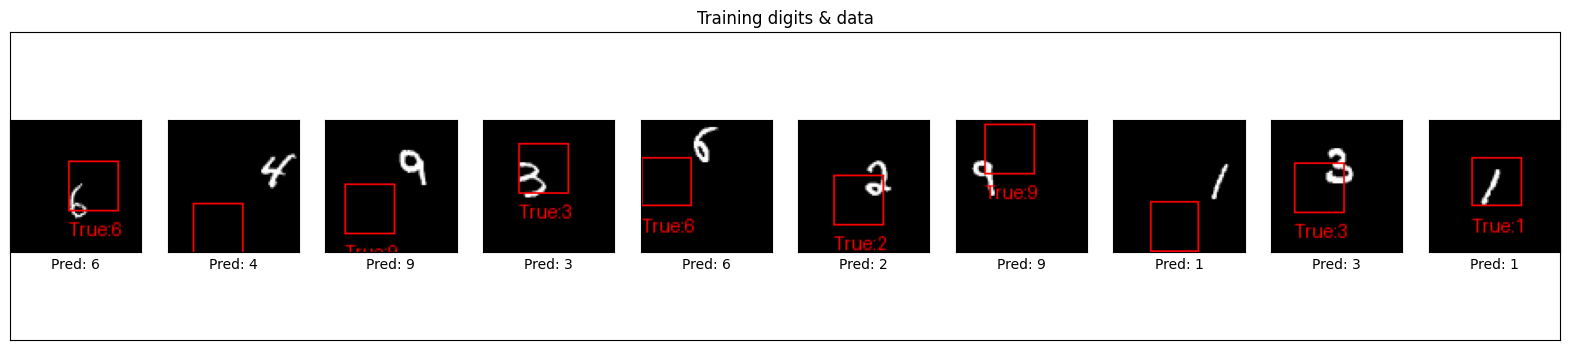

In [ ]:
display_digits_with_boxes(training_digits,training_labels,
                          training_labels,np.array([]),training_bboxes,
                          np.array([]),'Training digits & data')

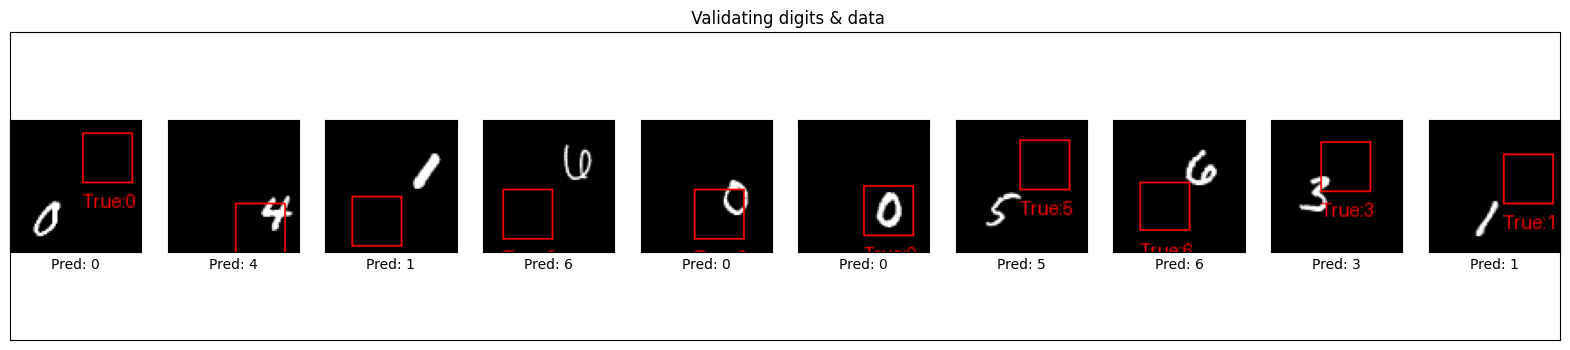

In [ ]:
display_digits_with_boxes(validation_digits,validation_labels,
                          validation_labels,np.array([]),validation_bboxes,
                          np.array([]),' Validating digits & data')

DEFINING THE NETWORK

In [ ]:
def feature_extractor(input):
  x=tf.keras.layers.Conv2D(16,activation='relu',kernel_size=3,input_shape=(75,75,1))(inputs)
  x=tf.keras.layers.AveragePooling2D((2,2))(x)

  x=tf.keras.layers.Conv2D(32,activation='relu',kernel_size=3)(x)
  x=tf.keras.layers.AveragePooling2D((2,2))(x)

  x=tf.keras.layers.Conv2D(64,activation='relu',kernel_size=3)(x)
  x=tf.keras.layers.AveragePooling2D((2,2))(x)
  return x

In [ ]:
def dense_layers(inputs):
  x=tf.keras.layers.Flatten()(inputs)
  x=tf.keras.layers.Dense(128,activation='relu')(x)
  return x

In [ ]:
def classifier(inputs):
  classification_output=tf.keras.layers.Dense(10,activation='softmax',name="classification")(inputs)
  return classification_output

In [ ]:
def bounding_box_regression(inputs):
  bounding_box_regression_output=tf.keras.layers.Dense(4,name="bounding_box")(inputs)
  return bounding_box_regression_output

In [ ]:
def final_model(inputs):
  feature_cnn=feature_extractor(inputs)
  dense_output=dense_layers(feature_cnn)

  classification_output=classifier(dense_output)
  bounding_box_output=bounding_box_regression(dense_output)

  model=tf.keras.Model(inputs=inputs,outputs=[classification_output,bounding_box_output])

  return model

In [ ]:
def define_and_compile_model(inputs):
    model=final_model(inputs)

    model.compile(optimizer= 'adam',loss={'classification':'categorical_crossentropy','bounding_box':'mse'},
                  metrics = {'classification':'accuracy','bounding_box':'mse'})

    return model

In [ ]:
with strategy.scope():
  inputs = tf.keras.Input(shape=(75,75,1))
  model=define_and_compile_model(inputs)

  model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 75, 75, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 73, 73,    │        160 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d   │ (None, 36, 36,    │          0 │ conv2d[0][0]      │
│ (AveragePooling2D)  │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 34, 34,    │      4,640 │ average_pooling2… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_1 │ (None, 17, 17,    │          0 │ conv2d_1[0][0]    │
│ (AveragePooling2D)  │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 15, 15,    │     18,496 │ average_pooling2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_2 │ (None, 7, 7, 64)  │          0 │ conv2d_2[0][0]    │
│ (AveragePooling2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ average_pooling2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    401,536 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification      │ (None, 10)        │      1,290 │ dense[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bounding_box        │ (None, 4)         │        516 │ dense[0][0]       │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 426,638 (1.63 MB)

 Trainable params: 426,638 (1.63 MB)

 Non-trainable params: 0 (0.00 B)

Training

In [ ]:
EPOCHS = 5

steps_per_epoch = 100 #batchsize

history = model.fit(training_dataset,steps_per_epoch=steps_per_epoch,
                    epochs=EPOCHS,validation_data=validation_dataset,validation_steps=1)
loss,classification_loss,bounding_box_loss,classification_acc,bounding_box_mse = model.evaluate(validation_dataset,steps=1)
print("\n--------------------------------\n")
print("Validation Accuracy:",classification_acc)
print("\n--------------------------------\n")

Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 45s 416ms/step - bounding_box_loss: 0.0587 - bounding_box_mse: 0.0587 - classification_accuracy: 0.1168 - classification_loss: 2.2931 - loss: 2.3519 - val_bounding_box_loss: 0.0150 - val_bounding_box_mse: 0.0150 - val_classification_accuracy: 0.2235 - val_classification_loss: 2.0820 - val_loss: 2.0970
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 39s 396ms/step - bounding_box_loss: 0.0134 - bounding_box_mse: 0.0134 - classification_accuracy: 0.2476 - classification_loss: 1.9934 - loss: 2.0068 - val_bounding_box_loss: 0.0185 - val_bounding_box_mse: 0.0185 - val_classification_accuracy: 0.3473 - val_classification_loss: 1.6828 - val_loss: 1.7013
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 50s 498ms/step - bounding_box_loss: 0.0175 - bounding_box_mse: 0.0175 - classification_accuracy: 0.4205 - classification_loss: 1.5676 - loss: 1.5851 - val_bounding_box_loss: 0.0200 - val_bounding_box_mse: 0.0200 - val_classification_accuracy: 0.5415 - val_classification_loss: 

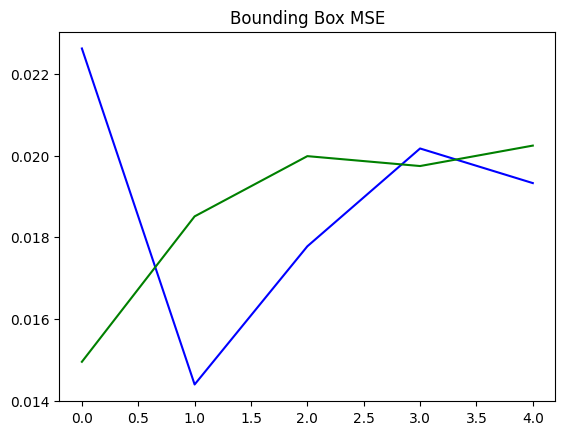

In [ ]:
plot_metrics("bounding_box_mse","Bounding Box MSE")

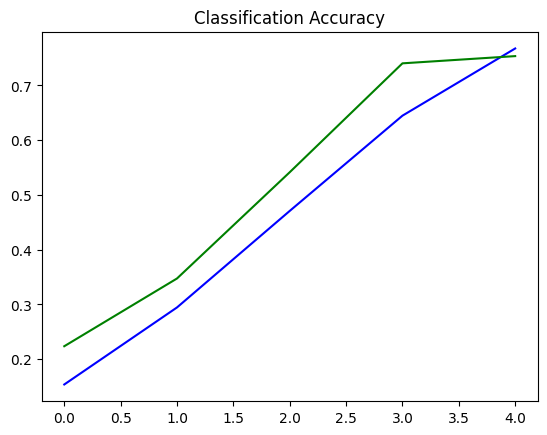

In [ ]:
plot_metrics("classification_accuracy","Classification Accuracy")

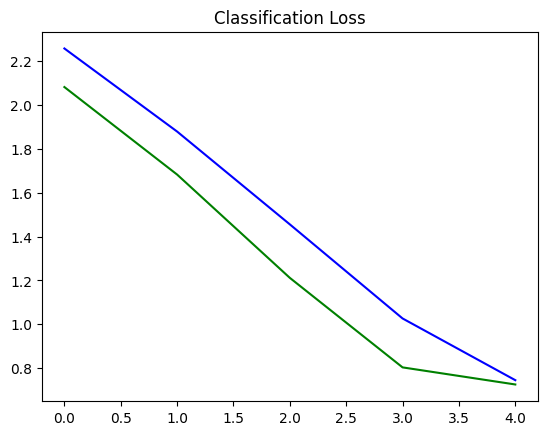

In [ ]:
plot_metrics("classification_loss","Classification Loss")

In [ ]:
def intersection_over_union(pred_box,true_box):
  xmin_pred,ymin_pred,xmax_pred,ymax_pred = np.split(pred_box,4,axis=-1)
  xmin_true,ymin_true,xmax_true,ymax_true = np.split(true_box,4,axis=-1)

  smoothing_factor=1e-10

  xmin_overlap = np.maximum(xmin_pred , xmin_true)
  xmax_overlap = np.minimum(xmax_pred , xmax_true)
  ymin_overlap = np.maximum(ymin_pred , ymin_true)
  ymax_overlap = np.minimum(ymin_pred , ymax_true)

  pred_box_area = (xmax_pred-xmin_pred)*(ymax_pred-ymin_pred)
  true_box_area = (xmax_true-xmin_true)*(ymax_true-ymin_true)

  overlap_area = np.maximum(xmax_overlap - xmin_overlap,0) * np.maximum((ymax_overlap - ymin_overlap),0)
  union_area = (pred_box_area + true_box_area) - overlap_area

  iou = (overlap_area + smoothing_factor) / (union_area + smoothing_factor)

  return iou

157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 77ms/step


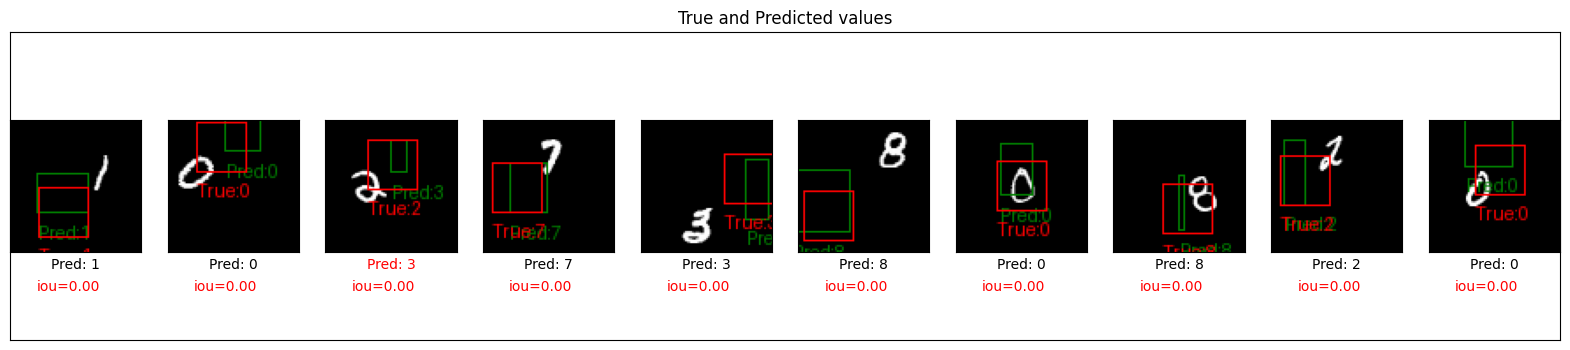

In [ ]:
prediction = model.predict (validation_digits,batch_size = 64)

prediction_labels = np.argmax(prediction[0], axis = 1)

prediction_bboxes = prediction[1]

iou = intersection_over_union(prediction_bboxes, validation_bboxes )

iou_threshold = 0.6

display_digits_with_boxes(validation_digits, prediction_labels, validation_labels, prediction_bboxes, validation_bboxes, iou, "True and Predicted values")

In [ ]:
#display_digits_with_boxes(validation_digits, prediction_labels, validation_labels, prediction_bboxes, validation_bboxes, iou, "True and Predicted values")